# Barley HvDRR

|                        |                                                      |
| ---------------------- | ---------------------------------------------------- |
| **Crop**               | Barley                                               |
| **Location**           | MPI Cologne (Y21) & HHU Dusseldorf (Y22), Germany    |
| **Year**               | 2021–2022                                            |
| **Measurements**       | 10,762                                               |
| **Genotypes**          | 641 F3 genotypes, 9 populations (77% coverage)       |
| **Owner**              | Benjamin Stich (Julius Kuhn Institute)               |
| **Protocols**          | Photosynthesis RIDES (Y21) + PSII measurements (Y22) |
| **PhotosynQ projects** | 12116, 12922, 16934                                  |

**Experiment:** QTL analysis of photosynthesis traits in HvDRR (Hordeum vulgare Diverse Resources for Resistance) F3 populations. Nine bi-parental crosses (HvDRR02, HvDRR25, HvDRR27, HvDRR31, HvDRR32, HvDRR34, HvDRR35, HvDRR40) plus inbred parental lines. Two years measured with different protocols:

- **2021 (MPI Cologne):** Photosynthesis RIDES protocol — actinic light = ambient PAR. Includes ECS, PSI, P700 parameters.
- **2022 (HHU Dusseldorf):** PSII measurements protocol — actinic light = 1500 umol/m2/s. PSII fluorescence only. ECS/PSI/P700 columns are NULL.

| Project | Year | Location       | Protocol | Measurements |
| ------- | ---- | -------------- | -------- | ------------ |
| 12116   | 2021 | MPI Cologne    | RIDES    | 2,495        |
| 12922   | 2021 | MPI Cologne    | RIDES    | 2,392        |
| 16934   | 2022 | HHU Dusseldorf | PSII     | 5,872        |

**Excluded measurements (2,490 NULL genotype):** 13 additional barley inbred lines not part of the HvDRR study, plus measurements with SPAD < 10 (quality filter by Yanrong Gao).

**Population sizes:**

| Population | Measurements |
| ---------- | ------------ |
| HvDRR31    | 2,117        |
| HvDRR27    | 1,361        |
| HvDRR25    | 1,130        |
| HvDRR02    | 1,071        |
| HvDRR35    | 645          |
| HvDRR34    | 589          |
| Inbred     | 536          |
| HvDRR40    | 536          |
| HvDRR32    | 287          |

**Development stages:** ASP (anthesis + seed production), REP (reproductive), SEP (seed ripening/senescence).

**Computed columns (29):** Union of RIDES + PSII protocols. Same as RIDES 2.0 (see Dataset 4) but without `leaf_thickness`. ECS, PSI, P700, and Leaf Angle columns are NULL for project 16934.

**Additional column:** `sample_raw` (VARIANT).

**Co-authorship condition:** Any manuscript using this data must include Yanrong Gao, Po-Ya Wu, Shizue Matsubara, and Benjamin Stich as co-authors.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data import load_barley_hvdrr

df = load_barley_hvdrr(Path("data"))
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Shape: (10762, 56)
Columns: ['measurement_id', 'project_id', 'protocol_name', 'user_id', 'device_id', 'status', 'timestamp', 'latitude', 'longitude', 'genotype', 'Population', 'Env', 'Year', 'Location', 'Block', 'field_range', 'field_row', 'zadoks_score', 'development_stage', 'Check', 'measurement_par', 'sample_raw', 'note', 'project_description', 'project_location', 'Phi2', 'PhiNPQ', 'PhiNO', 'NPQt', 'LEF', 'qL', 'FmPrime', 'FoPrime', 'Fs', 'FvP_over_FmP', 'SPAD', 'Light_Intensity_PAR', 'Leaf_Temperature', 'Ambient_Temperature', 'Leaf_Temperature_Differenial', 'Leaf_Temperature_Differential', 'Ambient_Humidity', 'Ambient_Pressure', 'ECSt_mAU', 'ECS_tau', 'gHplus', 'vHplus', 'PS1_Active_Centers', 'PS1_Open_Centers', 'PS1_Over_Reduced_Centers', 'PS1_Oxidized_Centers', 'P700_DIRK_ampl', 'kP700', 'tP700', 'v_initial_P700', 'Leaf_Angle']


In [2]:
df.head()

,measurement_id,project_id,protocol_name,user_id,device_id,status,timestamp,latitude,longitude,genotype,...,vHplus,PS1_Active_Centers,PS1_Open_Centers,PS1_Over_Reduced_Centers,PS1_Oxidized_Centers,P700_DIRK_ampl,kP700,tP700,v_initial_P700,Leaf_Angle
0,2796215,12116,Photosynthesis RIDES,137315,63:00:08:94,submitted,2022-06-20 11:56:15.642000+00:00,0.000000,0.000000,NaN,...,0.014,0.748,0.526,0.434,0.040,-0.00001,-129.1545,-0.0077,0.001291,3.468
1,2130860,12116,Photosynthesis RIDES,137333,52:00:12:b3,submitted,2021-06-29 09:08:33.276000+00:00,51.178397,6.802865,NaN,...,0.136,5.402,1.714,0.514,-1.228,0.00027,243.7367,0.0041,0.065809,24.331
2,2130858,12116,Photosynthesis RIDES,137333,52:00:12:b3,submitted,2021-06-29 09:07:58.590000+00:00,51.178427,6.802809,NaN,...,0.089,0.915,1.892,0.250,-1.142,0.00050,181.5558,0.0055,0.090778,12.380
3,2130856,12116,Photosynthesis RIDES,137333,52:00:12:b3,submitted,2021-06-29 09:07:29.482000+00:00,51.178427,6.802809,NaN,...,0.099,3.394,0.452,0.194,0.355,0.00023,181.5657,0.0055,0.041760,11.384
4,2130850,12116,Photosynthesis RIDES,137333,52:00:12:b3,submitted,2021-06-29 09:06:02.972000+00:00,51.178410,6.802826,NaN,...,0.145,1.671,0.268,-0.115,0.847,0.00104,125.1971,0.0080,0.130205,17.415


## Exploratory Data Analysis

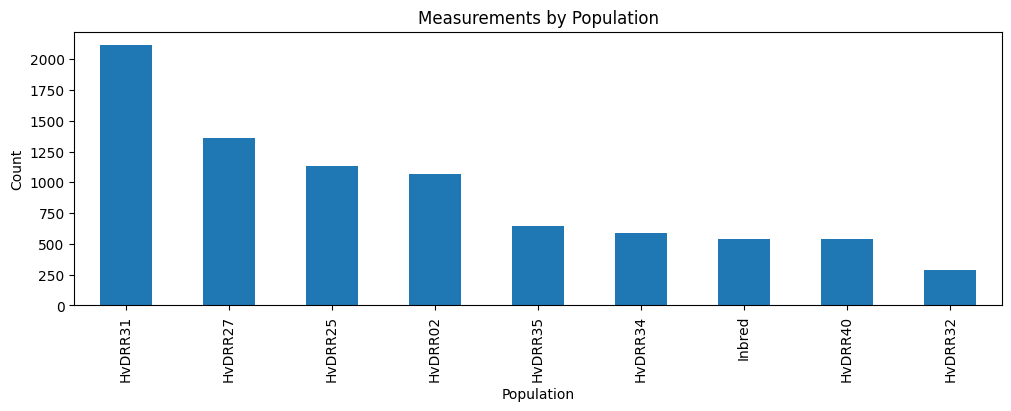

In [3]:
# Counts by Population
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
df["Population"].value_counts().sort_values(ascending=False).plot(kind="bar", ax=ax)
ax.set(title="Measurements by Population", xlabel="Population", ylabel="Count")
plt.show()

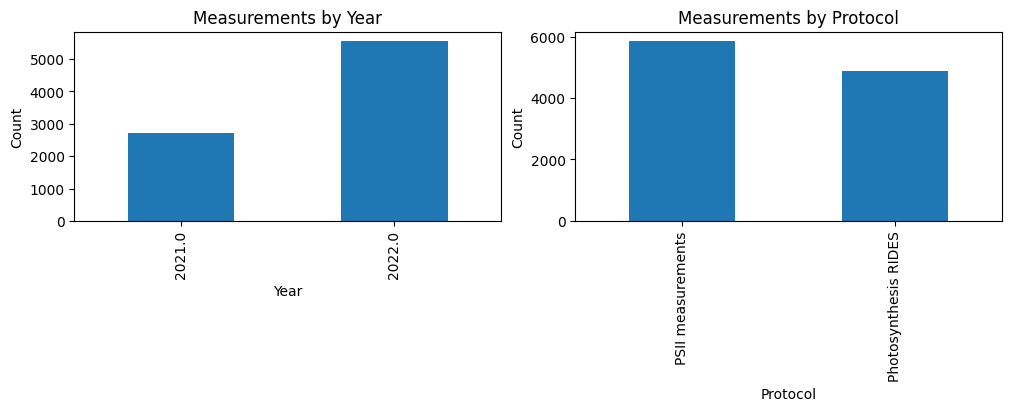

In [4]:
# Counts by Year / protocol_name
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")

df["Year"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set(title="Measurements by Year", xlabel="Year", ylabel="Count")

df["protocol_name"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set(title="Measurements by Protocol", xlabel="Protocol", ylabel="Count")

plt.show()

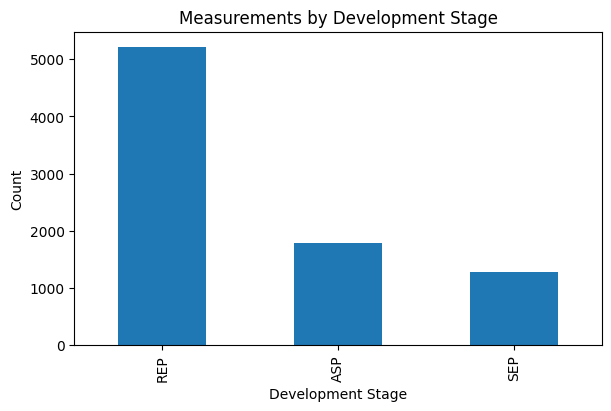

In [5]:
# Counts by development_stage
fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
df["development_stage"].value_counts().plot(kind="bar", ax=ax)
ax.set(
    title="Measurements by Development Stage",
    xlabel="Development Stage",
    ylabel="Count",
)
plt.show()

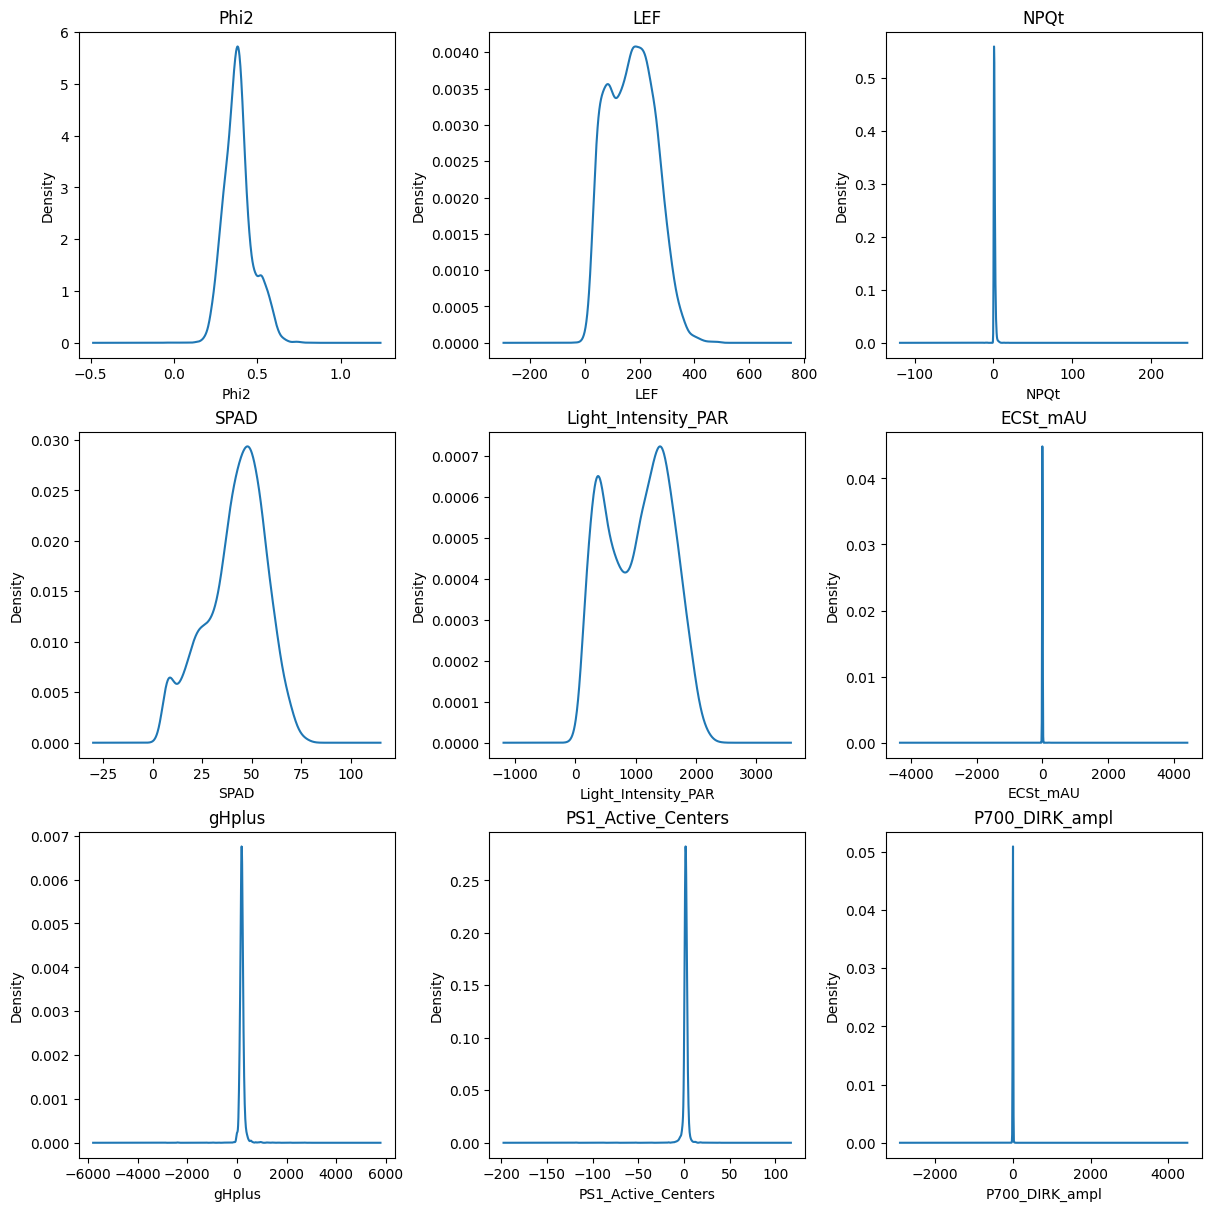

In [6]:
# 3x3 KDE grid of key traits
traits = [
    "Phi2",
    "LEF",
    "NPQt",
    "SPAD",
    "Light_Intensity_PAR",
    "ECSt_mAU",
    "gHplus",
    "PS1_Active_Centers",
    "P700_DIRK_ampl",
]

fig, axs = plt.subplots(3, 3, figsize=(12, 12), layout="constrained")

for ax, col in zip(axs.flatten(), traits):
    data = df[col].dropna()
    if len(data) > 1:
        data.plot(kind="kde", ax=ax)
    ax.set(title=col, xlabel=col)

plt.show()

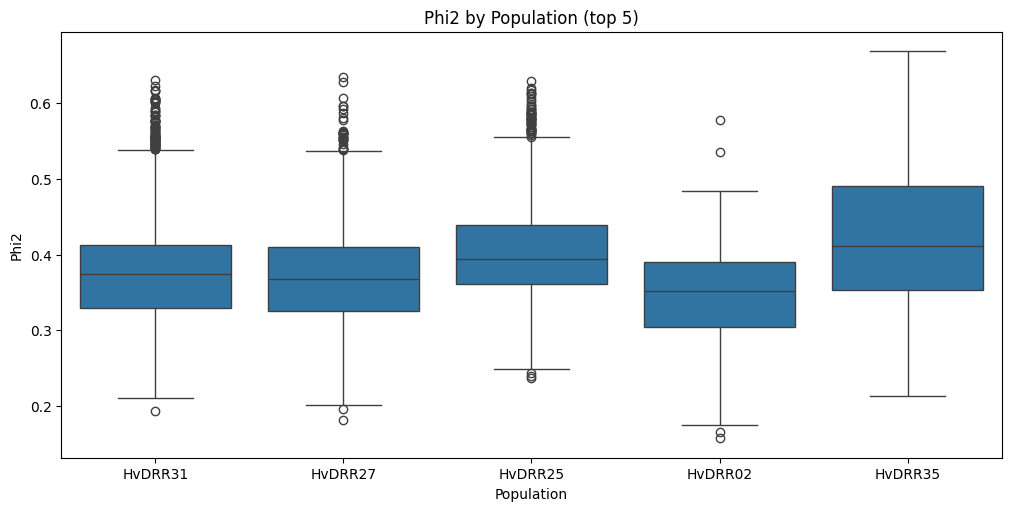

In [7]:
# Boxplot of Phi2 by Population (top 5 largest populations)
top5 = df["Population"].value_counts().head(5).index.tolist()
df_top5 = df[df["Population"].isin(top5)]

fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
sns.boxplot(data=df_top5, x="Population", y="Phi2", order=top5, ax=ax)
ax.set(title="Phi2 by Population (top 5)")
plt.show()

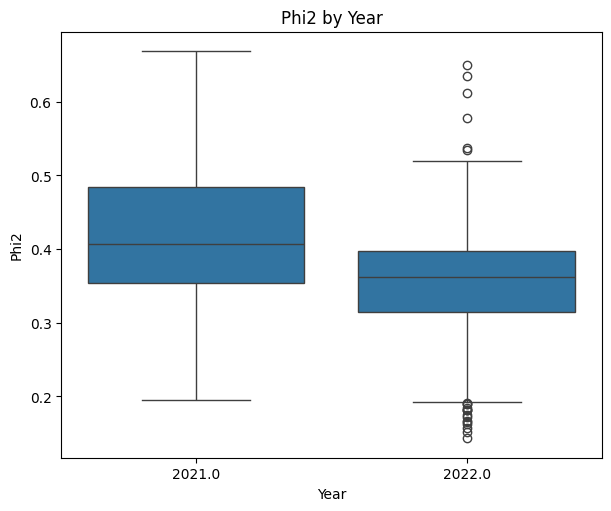

In [8]:
# Boxplot of Phi2 by Year
fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
sns.boxplot(data=df, x="Year", y="Phi2", ax=ax)
ax.set(title="Phi2 by Year")
plt.show()

In [9]:
df.describe()

,latitude,longitude,Year,field_range,field_row,zadoks_score,measurement_par,Phi2,PhiNPQ,PhiNO,...,vHplus,PS1_Active_Centers,PS1_Open_Centers,PS1_Over_Reduced_Centers,PS1_Oxidized_Centers,P700_DIRK_ampl,kP700,tP700,v_initial_P700,Leaf_Angle
count,10762.000000,10762.000000,8272.000000,8272.000000,8272.000000,8272.000000,8272.000000,10755.000000,10756.000000,10756.000000,...,4870.000000,4884.000000,4876.000000,4876.000000,4876.000000,4882.000000,4882.000000,4.882000e+03,4882.000000,4884.000000
mean,44.949223,6.000680,2021.673356,14.747099,13.847437,49.104086,1352.523522,0.387223,0.320331,0.292391,...,0.106108,1.825201,0.541068,0.312551,0.146365,0.527025,193.880383,-1.658479e+03,0.089049,15.944815
std,16.647521,2.222535,0.469014,11.240670,7.891703,17.541864,355.116982,0.088026,0.106935,0.097297,...,0.344989,3.994511,4.627169,13.484188,10.919191,41.242165,1129.018080,1.185940e+05,0.099087,11.574909
min,0.000000,0.000000,2021.000000,1.000000,1.000000,21.000000,55.975000,-0.054000,-0.213000,-0.094000,...,-18.032000,-118.829000,-142.644000,-240.475000,-739.356000,-1058.796300,-52874.562600,-8.285861e+06,-2.435837,0.000000
25%,50.960481,6.802878,2021.000000,5.000000,8.000000,32.000000,1476.212000,0.329500,0.246000,0.221000,...,0.071000,1.239750,0.283000,-0.062000,0.023750,0.000200,163.700100,3.500000e-03,0.041142,7.800000
50%,51.171025,6.810909,2022.000000,12.000000,12.000000,51.000000,1500.000000,0.379000,0.315000,0.280000,...,0.112000,1.974000,0.474500,0.228500,0.241000,0.000390,216.444250,4.500000e-03,0.089125,13.254000
75%,51.171184,6.811523,2022.000000,24.000000,17.000000,59.000000,1500.000000,0.430000,0.389000,0.355000,...,0.151000,2.809250,0.681000,0.474000,0.521250,0.000590,275.746475,5.900000e-03,0.136812,21.188750
max,51.190329,6.988632,2022.000000,38.000000,40.000000,83.000000,2070.217000,0.807000,0.980000,0.778000,...,4.581000,38.456000,265.071000,883.000000,73.128000,2639.740480,19468.731100,4.944944e+04,1.214803,164.222000
